# Zernike Aberrations and Astigmatism

This notebook demonstrates the application of Zernike polynomial aberrations to PSF computation, with a focus on astigmatism.

## Import Libraries

In [1]:
import math
from psf_generator.propagators import VectorialCartesianPropagator
from psf_generator.utils.plots import plot_pupil, plot_psf

## Zernike Polynomials

Zernike polynomials form an orthogonal basis for representing wavefront aberrations over a circular pupil. They are widely used to characterize optical aberrations in imaging systems.

**Common aberrations:**
- Index 0-2: Piston, tip, tilt
- Index 3-4: Defocus, astigmatism (oblique)
- Index 5: Astigmatism (vertical/horizontal)
- Higher indices: Coma, trefoil, spherical aberration, etc.

Aberrations are specified via `zernike_coefficients`, a list where each element is the coefficient for the corresponding Zernike mode.

## Astigmatism

We introduce astigmatism by setting a nonzero coefficient for the 6th Zernike polynomial (index 5). This aberration causes the PSF to elongate differently in orthogonal directions at different axial positions.

In [2]:
kwargs = {
    'n_pix_pupil': 257,
    'n_pix_psf': 256,
    'na': 1.3,
    'wavelength': 632,
    'pix_size': 10,
    'defocus_step': 3,
    'n_defocus': 300,
    'e0x': math.sqrt(2) / 2,
    'e0y': math.sqrt(2) / 2 * 1j,
    'zernike_coefficients': [0, 0, 0, 0, 0, 1]
}
propagator = VectorialCartesianPropagator(**kwargs)
psf = propagator.compute_focus_field()
pupil = propagator.get_pupil()

## Visualization at Multiple Z-Positions

Astigmatism manifests as a rotation of the PSF ellipticity along the optical axis. We visualize xy planes at three z-positions to observe this effect.

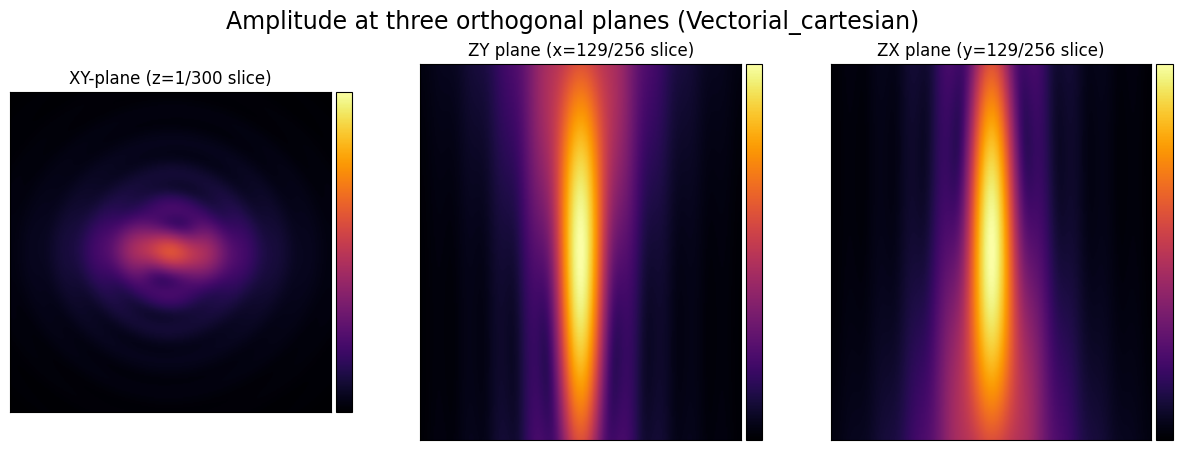

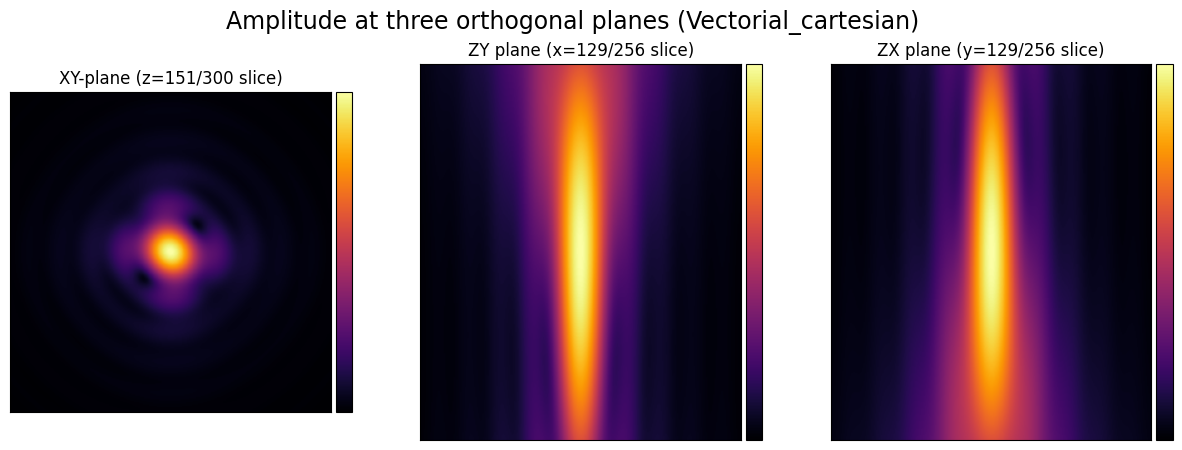

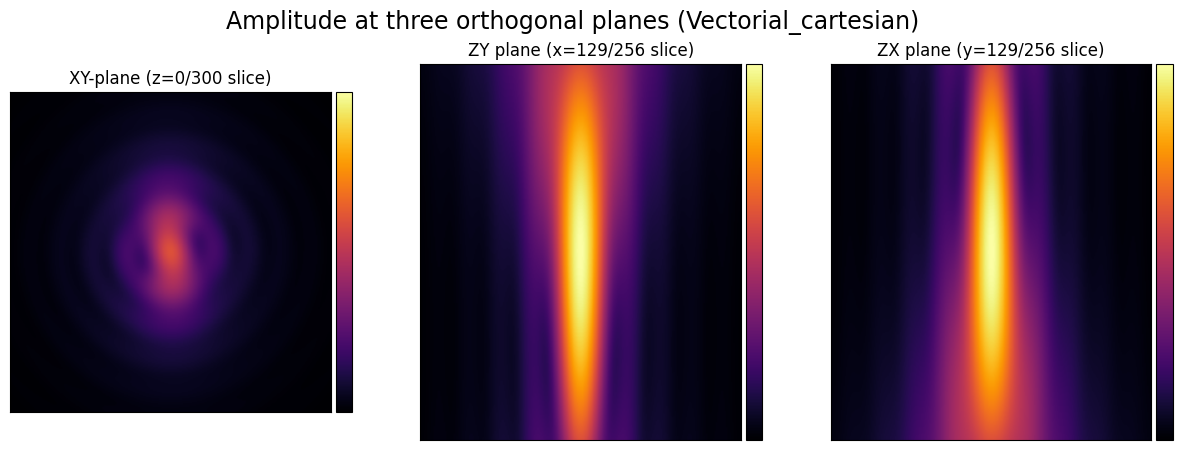

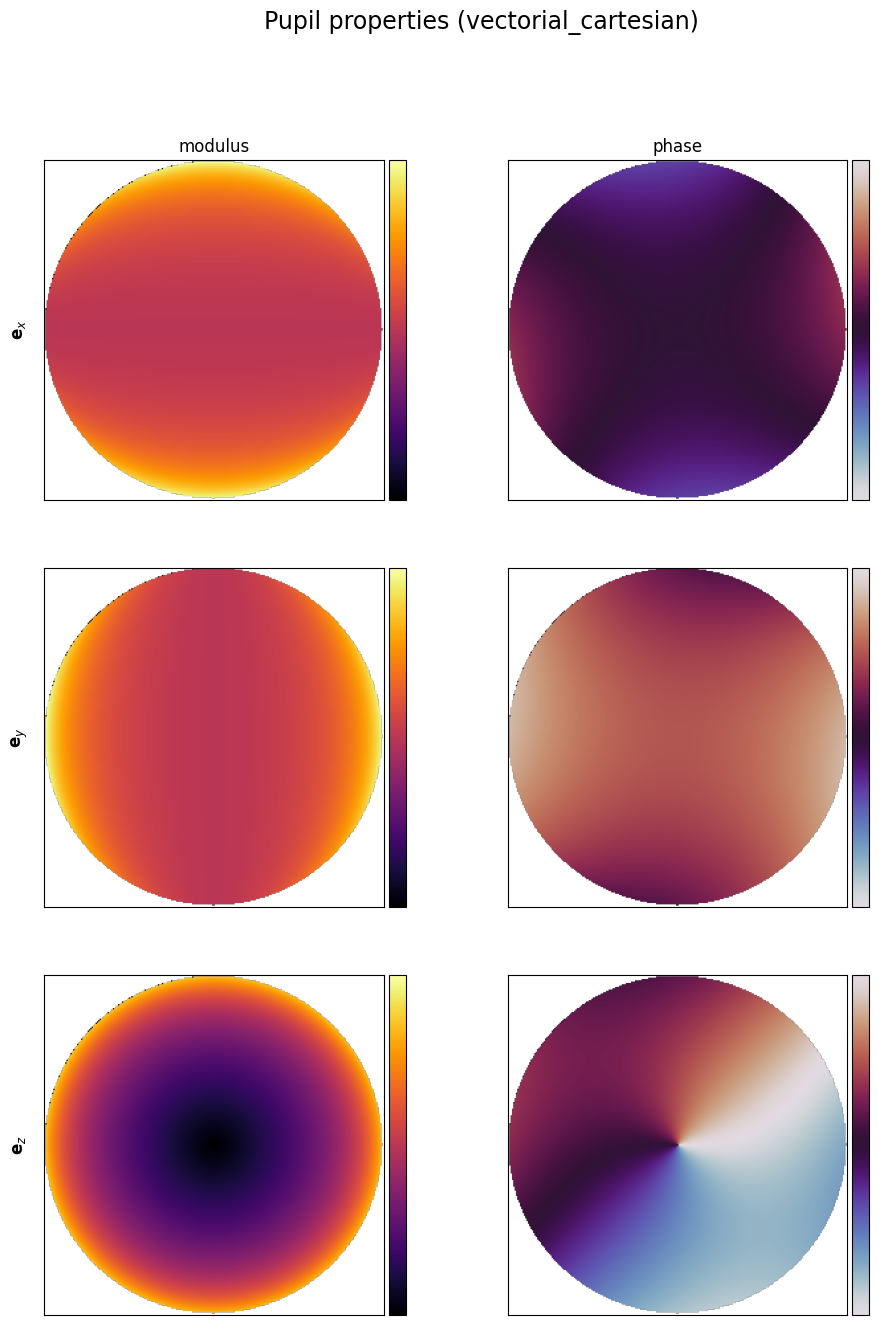

In [3]:
central_slice_n = kwargs['n_defocus'] // 2
for slice_n in [0, central_slice_n, -1]:
    plot_psf(
        psf=psf,
        name_of_propagator=propagator.get_name(),
        quantity='amplitude',
        show_titles=True,
        z_slice_number=slice_n
    )

plot_pupil(
    pupil,
    name_of_propagator=propagator.get_name()
)

The PSF exhibits characteristic astigmatic behavior: elongation direction rotates 90° between planes above and below focus. The pupil phase shows the saddle-shaped wavefront characteristic of astigmatism.

## Troubleshooting

**Zernike coefficient ordering:**
- Coefficients follow the Noll indexing convention
- List length determines number of modes included
- Unused coefficients should be set to 0

**Combining aberrations:**
- Multiple Zernike modes can be combined by setting multiple coefficients
- Can be used with `special_phase_mask` for custom aberrations

**Astigmatism-specific notes:**
- Reduce `defocus_step` to better resolve z-dependent PSF changes
- The coefficient magnitude controls aberration strength

**Propagator requirements:**
- Zernike aberrations work with both Cartesian and Spherical propagators
- Use Cartesian for pupil visualization and non-symmetric aberrations

**Performance:**
- Zernike computation adds minimal overhead
- Cost scales with number of nonzero coefficients